# Connectogram

In [46]:
import collections, itertools, textwrap
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pycirclize


In [47]:
CODE_DIR = Path.cwd()
PROJECT_ROOT = CODE_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"

mapping_file_path = DATA_DIR / "atlasmapping" / "CombinedMapping.csv"
edge_mask_file_path = DATA_DIR / "cleaned_matrices" / "original_edge_mask.npy"
bsr_lv1_file_path = PROJECT_ROOT / "old" / "connectogram" / "data" / "bsr_lv1_full.npy"
# (or move/copy bsr into DATA_DIR and point there)

combined_mapping = pd.read_csv(mapping_file_path)
edge_mask = np.load(edge_mask_file_path)
bsr = np.load(bsr_lv1_file_path)


In [48]:
mapping_size = len(combined_mapping)
expected_edges = mapping_size * (mapping_size - 1) // 2
print("Parcels:", mapping_size)
print("Expected edges:", expected_edges)
print("edge_mask length:", len(edge_mask))
print("bsr length:", len(bsr))
assert len(edge_mask) == expected_edges
assert len(bsr) == expected_edges


Parcels: 400
Expected edges: 79800
edge_mask length: 79800
bsr length: 79800


In [49]:
import pandas as pd
import numpy as np
import itertools
import collections

def get_contiguous_mapping(mapping, network_data_labels, network_group_names):
    """Group parcels into networks by sorting so parcels are contiguous within each network."""
    contiguous_mapping = mapping.copy()
    network_names = {}
    for column_label, group_name in zip(network_data_labels, network_group_names):
        names = mapping[column_label].unique().tolist()
        contiguous_mapping[column_label] = pd.Categorical(
            mapping[column_label], categories=names, ordered=True
        )
        network_names[group_name] = names

    contiguous_mapping.sort_values(by=network_data_labels, inplace=True)
    contiguous_mapping.reset_index(names="ParcelIndex", inplace=True)

    index_map = (
        pd.Series(contiguous_mapping.index, index=contiguous_mapping["ParcelIndex"])
        .sort_index()
        .to_numpy()
    )
    return network_names, contiguous_mapping, index_map

def get_grouping_info(contiguous_mapping, network_names, network_data_labels):
    """Determine parcel index ranges for each network label (for plotting group arcs)."""
    groups = []
    for group, label in zip(network_names, network_data_labels):
        names = network_names[group]
        sizes = contiguous_mapping.groupby(label, observed=False).size().to_numpy()
        cumulative_sizes = sizes.cumsum()
        tails = (cumulative_sizes - 1).tolist()
        heads = (cumulative_sizes - sizes).tolist()
        limits = zip(heads, tails)
        info = dict(zip(names, limits))
        groups.append(info)
    return groups

Connection = collections.namedtuple("Connection", ("head", "tail", "weight"))

def get_weighted_connections(indices, weights, mask=None, index_map=None):
    """Connections are (parcel_i, parcel_j, weight) for i<j in the given indices ordering."""
    ends = itertools.combinations(indices, 2)
    heads, tails = map(np.array, zip(*ends))

    if index_map is not None:
        heads, tails = index_map[heads], index_map[tails]

    if mask is not None:
        heads, tails, weights = heads[mask], tails[mask], weights[mask]

    connections = tuple(map(Connection._make, zip(heads.tolist(), tails.tolist(), weights.tolist())))
    return connections


## Process data

In [50]:
mapping_size = len(combined_mapping)

In [51]:
def get_contiguous_mapping(mapping, network_data_labels, network_group_names):
    """Group parcels into networks.

    Rearrange parcels so that those belonging to a network are contiguous.
    """
    contiguous_mapping = mapping.copy()
    network_names = {}
    for column_label, group_name in zip(network_data_labels, network_group_names):
        ## find names of network
        names = mapping[column_label].unique().tolist()
        ## set network names as categories for grouping
        contiguous_mapping[column_label] = pd.Categorical(mapping[column_label], categories=names, ordered=True)
        network_names[group_name] = names
    # group parcels (contigouous) by network names
    contiguous_mapping.sort_values(by=network_data_labels, inplace=True)
    contiguous_mapping.reset_index(names='ParcelIndex', inplace=True)
    # map from ungrouped parcel indices to grouped indices
    index_map = pd.Series(contiguous_mapping.index, index=contiguous_mapping['ParcelIndex']).sort_index().to_numpy()
    return network_names, contiguous_mapping, index_map

In [52]:
network_group_names = ['Networks-07', 'Networks-17']
# network data column labels in combined mapping
network_data_labels = ['Label7', 'Label17']


In [53]:
print(combined_mapping.columns.tolist())


['ParcelID', 'Label7', 'Label17', 'R', 'A', 'S']


In [54]:
# group parcels into networks
network_names, contiguous_mapping, index_map = get_contiguous_mapping(combined_mapping, network_data_labels, network_group_names)

In [55]:
def get_grouping_info(mapping, network_names, network_data_labels):
    """Determine size in number of parcels for each network in network groups."""
    groups = []
    for group, label in zip(network_names, network_data_labels):
        names = network_names[group]
        sizes = contiguous_mapping.groupby(label, observed=False).size().to_numpy()
        cumulative_sizes = sizes.cumsum()
        tails = (cumulative_sizes - 1).tolist()
        heads = (cumulative_sizes - sizes).tolist()
        limits = zip(heads, tails)
        info = dict(zip(names, limits))
        groups.append(info)
    return groups

In [56]:
groups = get_grouping_info(contiguous_mapping, network_names, network_data_labels)

A **Connection** is represented as a named tuple.

In [57]:
# named tuple to represent a connection
Connection = collections.namedtuple('Connection', ('head', 'tail', 'weight'))

In [58]:
def get_weighted_connections(indices, weights, mask=None, index_map=None):
    """Generate connection information between pairs of indices.

    Connections are represented as (parcel, parcel, weight).
    """
    # find pairs (combinations of 2) of indices
    ends = itertools.combinations(indices, 2)
    # remap indices
    heads, tails = map(np.array, zip(*ends))
    if index_map is not None:
        heads, tails = index_map[heads], index_map[tails]
    # mask values
    if mask is not None:
        heads, tails, weights = heads[mask], tails[mask], weights[mask]
    heads, tails, weights = heads.tolist(), tails.tolist(), weights.tolist()
    connections = tuple(map(Connection._make, zip(heads, tails, weights)))
    return connections

In [59]:
connections = get_weighted_connections(contiguous_mapping.index, bsr, edge_mask, index_map)

#### Verify

Compare with `edge_df` with positive bootstrap ratio (`positive = True`) and `top_n = 100` in `chord.ipynb`

In [60]:
sample_connections = sorted(connections, key=lambda connection: abs(connection.weight), reverse=True)[:100]

Sample connections with network (17 network) names of parcels.

In [61]:
[(contiguous_mapping['Label17'].iloc[[i, j]].tolist(), w) for i, j, w in sample_connections]


[(['17Networks_RH_DefaultB_PFCv_3', '17Networks_RH_TempPar_3'],
  5.206742911625353),
 (['17Networks_RH_ContB_Temp_2', '17Networks_RH_ContB_PFCld_4'],
  5.1614515348431595),
 (['17Networks_LH_ContA_IPS_2', '17Networks_RH_LimbicA_TempPole_5'],
  5.0772416151062645),
 (['17Networks_RH_DefaultB_PFCd_3', '17Networks_RH_TempPar_3'],
  4.81132527752163),
 (['17Networks_RH_ContB_IPL_4', '17Networks_RH_DefaultB_PFCd_4'],
  4.733332606851345),
 (['17Networks_LH_DefaultC_IPL_1', '17Networks_RH_ContB_IPL_3'],
  4.688841943378734),
 (['17Networks_LH_VisCent_ExStr_7', '17Networks_LH_SalVentAttnB_Ins_2'],
  4.681864976001955),
 (['17Networks_RH_DefaultB_PFCd_3', '17Networks_RH_TempPar_6'],
  4.667203858461166),
 (['17Networks_RH_SalVentAttnB_IPL_1', '17Networks_RH_LimbicA_TempPole_5'],
  4.621328969990398),
 (['17Networks_RH_VisPeri_ExStrSup_1', '17Networks_RH_ContB_IPL_1'],
  4.6021464203884035),
 (['17Networks_RH_DorsAttnB_PostC_5', '17Networks_RH_LimbicA_TempPole_2'],
  4.59135647216976),
 (['17N

## Plot

### Plotter

In [62]:
class Connectogram:

    def __init__(self):
        # sector parameters
        self.sector_start, self.sector_end = 0.0, 1.0
        self.sector_size = self.sector_end - self.sector_start
        self.sector_range = (self.sector_start, self.sector_end)
        # radius limit
        self.r_max = 100.0
        # plot elements
        self.linewidth = 0.1
        self.edgecolor = '0.2'

    def plot(self, axes, segments, groups, connections, colors):
        # colors
        self.edgecolor = colors['edge']
        circos = self._layout(segments, groups, colors)
        self._connections(circos, connections, colors['connections'])
        # draw
        circos.plotfig(ax=axes)

    def _group(self, circos, group, colormap, r_max, width=10.0):
        """Add group elements."""
        r_min = r_max - width
        r_lim = (r_min, r_max)
        r_center = 0.5 * sum(r_lim)
        colors = itertools.cycle(colormap.colors)
        for (name, limits), color in zip(group.items(), colors):
            head, tail = limits
            head, _ = circos.sectors[head].deg_lim
            _, tail = circos.sectors[tail].deg_lim
            deg_lim = (head, tail)
            circos.rect(
                r_lim = r_lim,
                deg_lim = deg_lim,
                facecolor = color,
                edgecolor = self.edgecolor,
                linewidth=self.linewidth
            )
            # position of label text
            deg_center = 0.5 * sum(deg_lim)
            # break long lines
            name = textwrap.fill(name, width=15)
            # rotation of text
            is_bottom = 70.0 < deg_center < 250.0
            rotation = (180.0 - deg_center) if is_bottom else -deg_center
            circos.text(
                name,
                r = r_center,
                deg = deg_center,
                rotation = rotation,
                horizontalalignment = 'center',
                verticalalignment = 'center'
                )
        return r_min

    def _parcels(self, circos, color, r_max, width=2.0):
        """Add parcel elements."""
        r_min = r_max - width
        r_lim = (r_min, r_max)
        for sector in circos.sectors:
            track = sector.add_track(r_lim=r_lim)
            track.axis(facecolor=color, edgecolor=self.edgecolor, linewidth=self.linewidth)
        return r_min

    def _layout(self, segments, groups, colors):
        """Set layout of plot using parcels and groups."""
        sectors = dict.fromkeys(range(segments), self.sector_size)
        circos = pycirclize.Circos(sectors)
        # radius limit
        r_max = self.r_max
        # gap between groups
        gap = 1.0
        for group, colormap in zip(groups, colors['groups']):
            r_max = self._group(circos, group, colormap, r_max)
            r_max -= gap
        r_max = self._parcels(circos, colors['parcels'], r_max)
        return circos

    def _connections(self, circos, connections, colormap):
        """Add connections."""
        #ranges = tuple((sector.start, sector.end) for sector in circos.sectors)
        terminals = tuple(0.5 * (sector.start + sector.end) for sector in circos.sectors)
        for connection in connections:
            normalized_weight = colormap.norm(connection.weight)
            color = colormap.cmap(normalized_weight)
            #head, tail = (connection.head, *ranges[connection.head]), (connection.tail, *ranges[connection.tail])
            #circos.link(head, tail, color=color)
            head, tail = (connection.head, terminals[connection.head]), (connection.tail, terminals[connection.tail])
            circos.link_line(head, tail, color=color) 

### Figure

In [63]:
def get_figure(segments, groups, connections, colors, weight_label):
    figure = plt.figure()
    axes = figure.add_subplot(polar=True)
    
    # add connectogram
    connectogram = Connectogram()
    connectogram.plot(axes, segments, groups, connections, colors)
    # add colorbar
    colorbar = figure.colorbar(
        colors['connections'],
        ax = axes,
        shrink = 0.75,
        label=weight_label
    )
    return figure

In [64]:
def get_colors(settings, normalizer):
    """Process user defined colors."""
    # add normalizer to colormap of connections
    colors = settings.copy()
    colors['connections'] = matplotlib.cm.ScalarMappable(cmap=settings['connections'], norm=normalizer)
    return colors

## Selected figures

### Style

In [65]:
mpl_style = {
    # FONT
    'font.family': 'sans-serif',
    'font.sans-serif': 'LMSans10',
    'font.weight':'normal',
    'font.size': 6.0,
    # TEXT
    'text.color': 'black',
    # AXES
    'axes.labelsize': 8.0,
    # FIGURE
    'figure.titlesize': 12.0,
    'figure.figsize': (7.0, 7.0),
    'figure.constrained_layout.use': True,
    # SAVING FIGURES
    'savefig.dpi': 1200,
    'savefig.transparent': True, 
}

In [66]:
matplotlib.style.use(mpl_style)

### Colors

In [67]:
default_color_settings = {
    'edge': '#564f4f',
    'parcels': '#d8dbdc',
    'groups': [
        matplotlib.colors.ListedColormap(
            [
                '#c8a9d7',
                '#a1c9d8',
                '#a0d9c4',
                '#b59cd6',
                '#f9e9d8',
                '#f7bfa1',
                '#f0a0a2',
            ]
        ),
        matplotlib.colors.ListedColormap(
            [
                '#B980D6',
                '#FF8A8A',
                '#8FB9DF',
                '#9FE6CB',
                '#A8D58A',
                '#6FC27A',
                '#D8A8F0',
                '#FFC2E1',
                '#A5A96A',
                '#E6F8C9',
                '#FFC98A',
                '#B57A88',
                '#A3B3D1',
                '#FFF77A',
                '#E89AA0',
                '#7f8ab9',
                '#8FA6FF'
            ]
        )
    ],
    'connections': matplotlib.colormaps['RdYlGn'],
}

Normalizer for weights of selected connections for selecting colors.

In [68]:
def minmax_normalizer(connections, w_min=None, w_max=None, symmetric=False):
    """Normalizer using minimum and maximum of connection weights."""
    _, _, weights = zip(*connections)
    minimum, maximum = min(weights), max(weights)
    if ((minimum < 0.0) ^ (maximum < 0.0)) and symmetric:
        limit = max(abs(minimum), abs(maximum))
        minimum, maximum = (-limit, limit)
    minimum = minimum if w_min is None else w_min
    maximum = maximum if w_max is None else w_max
    normalizer = matplotlib.colors.Normalize(vmin=minimum, vmax=maximum)
    return normalizer

In [69]:
# normalizer based on ALL connections
default_normalizer = minmax_normalizer(connections, symmetric=True)

In [70]:
default_colors = get_colors(default_color_settings, default_normalizer)

### Output

In [71]:
import os


In [72]:
# output directory
output_dir = 'plots'
# create directory
os.makedirs(output_dir, exist_ok=True)

### Bootstrap ratios: Positive

#### Connections

In [73]:
def weight_positive(connections, number):
    """Get top connections with most positive weights."""
    selected = tuple(filter(lambda connection: connection.weight > 0.0, connections))
    selected = sorted(selected, key=lambda connection: connection.weight, reverse=True)[:number]
    return selected    

In [74]:
selected_connections = weight_positive(connections, 100)

#### Colors

In [75]:
color_settings = default_color_settings.copy()
color_settings['connections'] = matplotlib.colormaps['YlGn']

In [76]:
normalizer = minmax_normalizer(selected_connections, w_min=0.0)

In [77]:
colors = get_colors(color_settings, normalizer)

Text(0.5, 0.98, 'Bootstrap ratios: Positive - Top 100')

findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sa

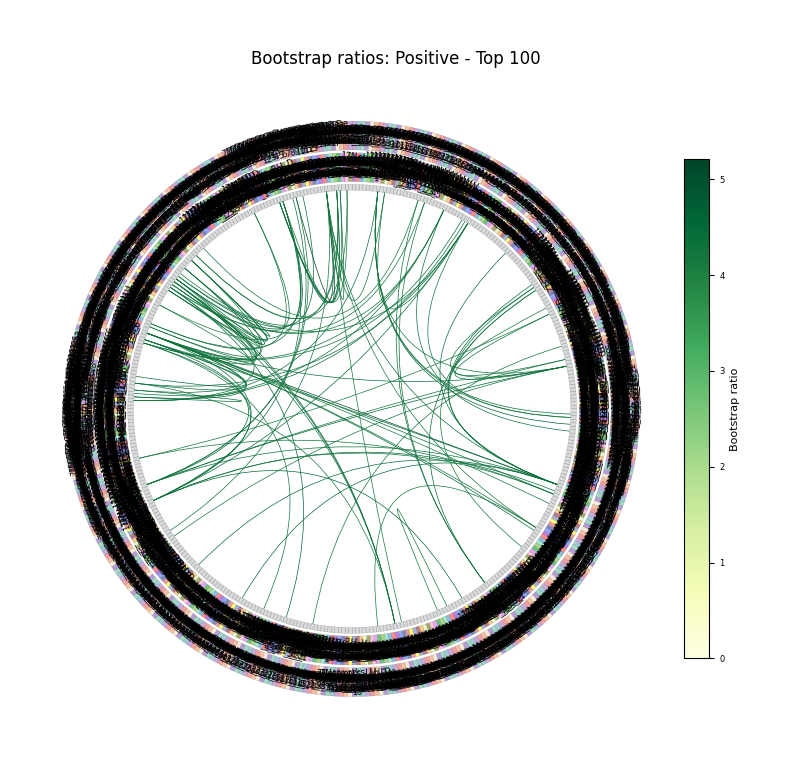

In [78]:
title = 'Bootstrap ratios: Positive - Top 100'
weight_label = 'Bootstrap ratio'
figure = get_figure(mapping_size, groups, selected_connections, colors, weight_label)
figure.suptitle(title)

In [79]:
# output
plot_file_name = 'bsr_positive.pdf'
plot_file_path = os.path.join(output_dir, plot_file_name)
figure.savefig(plot_file_path, dpi=1200)

findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sa

### Bootstrap ratios: Negative

#### Connections

In [80]:
def weight_negative(connections, number):
    """Get top connections with most negative weights."""
    selected = tuple(filter(lambda connection: connection.weight < 0.0, connections))
    selected = sorted(selected, key=lambda connection: connection.weight)[:number]
    return selected    

In [81]:
selected_connections = weight_negative(connections, 100)

#### Colors

In [82]:
color_settings = default_color_settings.copy()
color_settings['connections'] = matplotlib.colormaps['YlOrRd_r']

In [83]:
normalizer = minmax_normalizer(selected_connections, w_max=0.0)

In [84]:
colors = get_colors(color_settings, normalizer)

Text(0.5, 0.98, 'Bootstrap ratios: Negative - Top 100')

findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sa

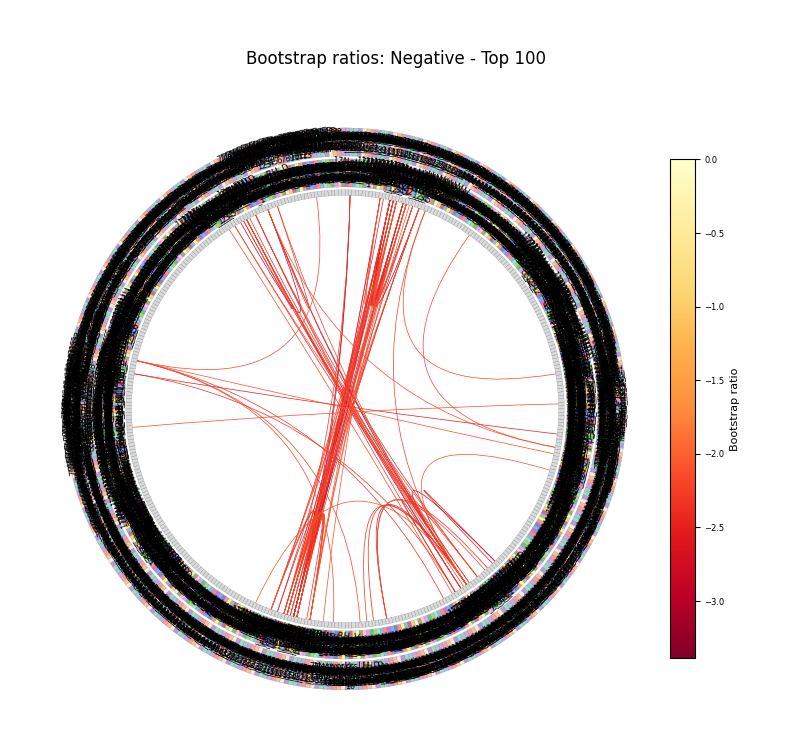

In [85]:
title = 'Bootstrap ratios: Negative - Top 100'
weight_label = 'Bootstrap ratio'
figure = get_figure(mapping_size, groups, selected_connections, colors, weight_label)
figure.suptitle(title)

In [86]:
# output
plot_file_name = 'bsr_negative.pdf'
plot_file_path = os.path.join(output_dir, plot_file_name)
figure.savefig(plot_file_path, dpi=1200)

findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sa

### Bootstrap ratios: Negative and Positive

#### Connections

In [87]:
selected_connections = weight_negative(connections, 100) + weight_positive(connections, 100)

#### Colors

In [88]:
color_settings = default_color_settings.copy()
color_settings['connections'] = matplotlib.colormaps['RdYlGn']

In [89]:
normalizer = minmax_normalizer(selected_connections, symmetric=True)

In [90]:
colors = get_colors(color_settings, normalizer)

Text(0.5, 0.98, 'Bootstrap ratios: Negative and Positive - Top 100')

findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sa

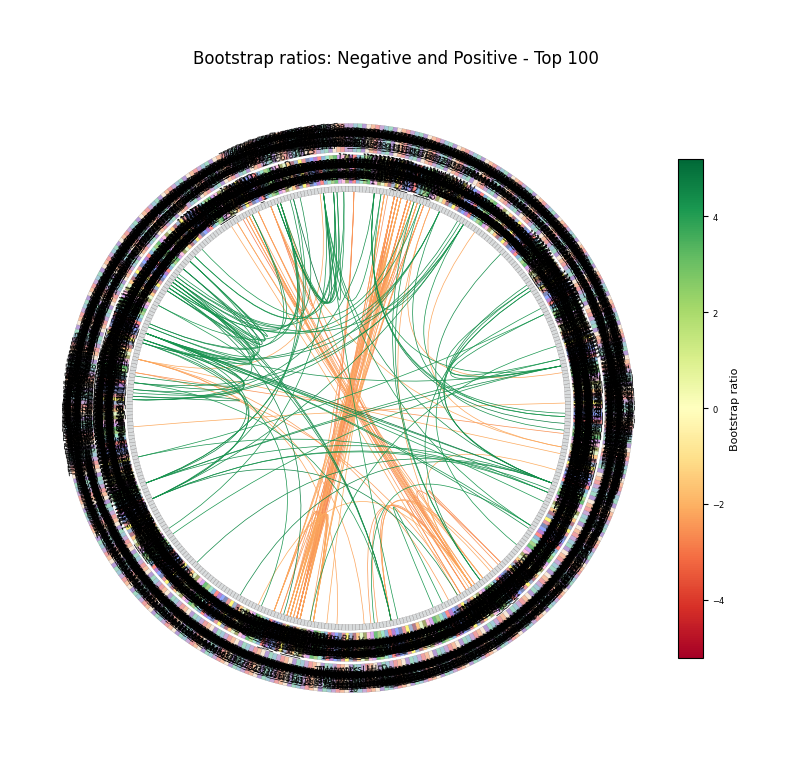

In [91]:
title = 'Bootstrap ratios: Negative and Positive - Top 100'
weight_label = 'Bootstrap ratio'
figure = get_figure(mapping_size, groups, selected_connections, colors, weight_label)
figure.suptitle(title)

In [ ]:
# output
plot_file_name = 'bsr_combined.pdf'
plot_file_path = os.path.join(output_dir, plot_file_name)
figure.savefig(plot_file_path, dpi=1200)

findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sans-serif' not found because none of the following families were found: LMSans10
findfont: Generic family 'sa